In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.operators.sampling.rnd import BinaryRandomSampling

algorithm = NSGA2(
    pop_size=200,
    n_offsprings=100,
    sampling=BinaryRandomSampling(),
    crossover=TwoPointCrossover(),
    mutation=BitflipMutation(),
    eliminate_duplicates=True,
)


In [152]:
from pymoo.termination import get_termination

termination = get_termination("n_gen", 40)


In [153]:
import numpy as np
from pymoo.core.problem import Problem
import pandas as pd

class MyProblem(Problem):
    def __init__(self, n_var=10, n_obj=1, n_ieq_constr=11):
        super().__init__(
            n_var=n_var, n_obj=n_obj, n_ieq_constr=n_ieq_constr, vtype=bool, xl=np.zeros(n_var), xu=np.ones(n_var)
        )

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = np.sum(100 * (x ** 2), axis=1)
        g1s = []
        dec_vars = x.shape[1]
        g0 = 4-np.sum(x, axis=1)
        df_x = pd.DataFrame(x)
        g1s = (df_x.mul(range(dec_vars), axis=1) - 6).values.T

        out["F"] = f1
        out["G"] = np.column_stack([g0, *g1s])



In [154]:
from pymoo.optimize import minimize
from pymoo.problems.single.knapsack import create_random_knapsack_problem

problem = create_random_knapsack_problem(30)

res = minimize(problem, algorithm, termination, seed=1, save_history=True, verbose=True)

print("Best solution found: %s" % res.X.astype(int))
print("Function value: %s" % res.F)
print("Constraint violation: %s" % res.CV)


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      200 |      1 |  1.810000E+02 |  5.010200E+02 |             - |             -
     2 |      300 |      1 |  1.530000E+02 |  3.953400E+02 |             - |             -
     3 |      400 |      1 |  8.400000E+01 |  3.291800E+02 |             - |             -
     4 |      500 |      1 |  1.0000000000 |  2.731250E+02 |             - |             -
     5 |      600 |      1 |  1.0000000000 |  2.242400E+02 |             - |             -
     6 |      700 |      1 |  1.0000000000 |  1.856850E+02 |             - |             -
     7 |      800 |      1 |  0.000000E+00 |  1.492850E+02 |             - |             -
     8 |      900 |      1 |  0.000000E+00 |  1.159650E+02 |  0.000000E+00 |             f
     9 |     1000 |      1 |  0.000000E+00 |  8.636000E+01 |  1.750000E+02 |         ideal
    10 |     1100 |      1 |  0.000000E+00 |  6.468000E+01 |  0.000000E+00 |             f

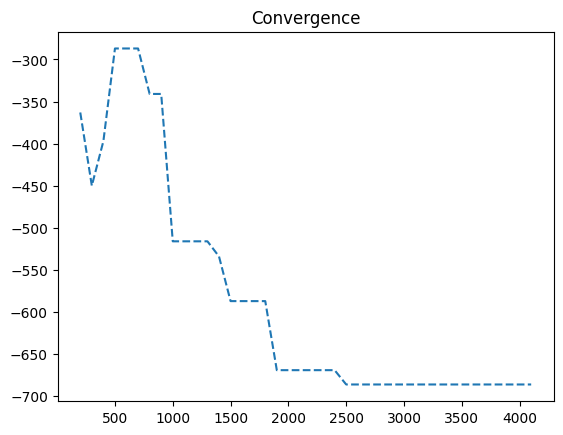

In [155]:
import numpy as np
import matplotlib.pyplot as plt

n_evals = np.array([e.evaluator.n_eval for e in res.history])
opt = np.array([e.opt[0].F for e in res.history])

plt.title("Convergence")
plt.plot(n_evals, opt, "--")
plt.show()


In [55]:
import numpy as np
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from pymoo.core.sampling import Sampling
import random
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.core.mutation import Mutation
from pymoo.core.crossover import Crossover


# === CONFIGURATION ===
n_pokemon = 1302
n_moves = 459
n_types = 18
n_stats = 6
LM = np.random.randint(0, 2, size=(n_pokemon, n_moves), dtype=bool)  # Replace with actual - Learnable Moves
ME = np.random.randint(20, 110, size=(2, n_moves), dtype=np.int64)  # Replace with actual - Move Effectiveness
# Make sure ME has only one value per column
for col in range(ME.shape[1]):
    row = random.randint(0, 1)
    ME[row, col] = 0
PT = np.random.randint(0, 2, size=(n_pokemon, n_types), dtype=bool)  # Replace with actual - Pokémon Types
MT = np.random.randint(0, 2, size=(n_moves, n_types), dtype=bool)  # Replace with actual - Move Types
PS = np.random.randint(20, 110, size=(n_pokemon, n_stats), dtype=np.int64)  # Replace with actual - Pokémon Stats
Att = [0, 1, 1, 0, 0, 0] # Replace with actual - Vector to chose attack and special attack stats


# === PROBLEM WITH CONSTRAINTS ===
class PokemonTeamProblemWithConstraints(Problem):
    def __init__(self, LM=LM, ME=ME, n_pokemon=n_pokemon, n_moves=n_moves):
        self.n_pokemon = n_pokemon
        self.n_moves = n_moves
        self.LM = LM.astype(bool)  # Learnable Moves
        self.ME = ME.astype(np.int64)  # Move Effectiveness
        super().__init__(
            n_var=n_pokemon + n_pokemon * n_moves,
            n_obj=1,
            n_ieq_constr=1 + n_pokemon + n_pokemon * n_moves * 2,
            xl=0,
            xu=1,
            type_var=np.bool_
        )

    def _evaluate(self, X, out, *args, **kwargs):
        F = []
        G = []

        for ind in X:
            x = ind[:n_pokemon].astype(bool)
            y = ind[n_pokemon:].reshape(n_pokemon, n_moves).astype(bool)

            # === Objectives ===
            damage = np.matmul(y, ME.T).sum()
            # coverage = np.unique(np.argmax(y, axis=1)).size  # dummy coverage
            F.append([-damage])  # negative = maximize

            # === Constraints ===
            constraints = []

            # (1) No more than 6 Pokémon
            constraints.append(x.sum(dtype=np.int8) - 6)

            # (2) For each selected Pokémon: sum of moves == 4
            for i in range(n_pokemon):
                if x[i]:
                    constraints.append(abs(y[i].sum(dtype=np.int8) - 4))
                else:
                    constraints.append(y[i].sum())  # if not selected, must have 0 moves

            # (3) Y_ij ≤ X_i (can't choose moves if Pokémon is not selected)
            constraints += list((y & ~x[:, np.newaxis]).flatten())

            # (4) Y_ij ≤ LM_ij (only moves it can learn)
            constraints += list((y & ~LM).flatten())

            G.append(constraints)

        out["F"] = np.column_stack(F)
        out["G"] = np.column_stack(G)
        print("Objectives (F):")
        print(out["F"])
        print("Constraints (G):")
        print(out["G"].sum(axis=0))


class PokemonTeamSampling(Sampling):
    def __init__(self, LM=LM, n_pokemon=n_pokemon, n_moves=n_moves):
        super().__init__()
        self.LM = LM.astype(bool)
        self.n_pokemon = n_pokemon
        self.n_moves = n_moves

    def _do(self, problem, n_samples, **kwargs):
        individuals = []

        for _ in range(n_samples):
            # (1) Select 6 unique Pokémon
            selected = np.zeros(self.n_pokemon, dtype=np.uint8)
            team = np.random.choice(self.n_pokemon, 6, replace=False)
            selected[team] = 1

            # (2) Assign 4 legal moves to each selected Pokémon
            moves = np.zeros((self.n_pokemon, self.n_moves), dtype=np.uint8)

            for i in team:
                legal_moves = np.where(self.LM[i])[0]
                if len(legal_moves) >= 4:
                    chosen = np.random.choice(legal_moves, 4, replace=False)
                    moves[i, chosen] = 1
                else:
                    # Optional: fallback to random other Pokémon if not enough moves
                    chosen = np.random.choice(
                        legal_moves, len(legal_moves), replace=False
                    )
                    moves[i, chosen] = 1

            # Flatten and concatenate
            indiv = np.concatenate([selected, moves.flatten()])
            individuals.append(indiv)

        return np.array(individuals)


class PokemonMutation(Mutation):
    def __init__(self, prob_pokemon=0.01, prob_move=0.001):
        super().__init__()
        self.prob_pokemon = prob_pokemon
        self.prob_move = prob_move

    def _do(self, problem, X, **kwargs):
        n_pokemon = problem.n_pokemon
        n_moves = problem.n_moves
        # Turning off mutations for debuggin crossover
        return X
        for i in range(len(X)):
            individual = X[i]

            # --- Pokémon mutation
            for j in range(n_pokemon):
                if np.random.rand() < self.prob_pokemon:
                    individual[j] = 1 - individual[j]

            # --- Move mutation
            moves = individual[n_pokemon:].reshape(n_pokemon, n_moves)
            for p in range(n_pokemon):
                for m in range(n_moves):
                    if np.random.rand() < self.prob_move:
                        moves[p, m] = 1 - moves[p, m]

            X[i] = np.concatenate([individual[:n_pokemon], moves.flatten()])

        return X



class PokemonCrossover(Crossover):
    def __init__(self, prob_pokemon=0.5, prob_move=0.5):
        super().__init__(2, 2)  # 2 parents → 2 offspring
        self.prob_pokemon = prob_pokemon
        self.prob_move = prob_move

    def _do(self, problem, X, **kwargs):
        n_parents, n_matings, n_vars = X.shape
        n_pokemon = problem.n_pokemon
        n_moves = problem.n_moves

        
        offspring = np.empty_like(X)

        for k in range(n_matings):
            parent1 = X[0][k]
            parent2 = X[1][k]

            # CASE 1: If both parents are identical, just copy them
            if np.all(parent1 == parent2):
                offspring[0][k] = parent1.copy()
                offspring[1][k] = parent2.copy()
                continue

            # Split into X and Y
            x1, y1 = (
                parent1[:n_pokemon],
                parent1[n_pokemon:].reshape(n_pokemon, n_moves),
            )
            x2, y2 = (
                parent2[:n_pokemon],
                parent2[n_pokemon:].reshape(n_pokemon, n_moves),
            )
            

            child1_flag = np.random.rand() < self.prob_pokemon # True if child1 is based on parent 1, False if based on parent 2
            child2_flag = np.random.rand() > self.prob_pokemon # True if child2 is based on parent 1, False if based on parent 2
            child1 = np.where(child1_flag, parent1, parent2)
            child2 = np.where(child2_flag, parent1, parent2)

            child1_x, child1_y = (
                child1[:n_pokemon],
                child1[n_pokemon:].reshape(n_pokemon, n_moves),
            )
            child2_x, child2_y = (
                child2[:n_pokemon],
                child2[n_pokemon:].reshape(n_pokemon, n_moves),
            )


            pokemon_indexes1 = (x1 > 0).nonzero()[0]
            n_crossovers = np.random.randint(1, pokemon_indexes1.shape[0]-1)
            crossover_points1 = np.random.choice(pokemon_indexes1, n_crossovers, replace=False)
            pokemon_indexes2 = (x2 > 0).nonzero()[0]
            crossover_points2 = np.random.choice(pokemon_indexes2, n_crossovers, replace=False)


            # First set to zero the pokemon and moves getting deleted. Important in case a move is deleted from parent 1 but moved over from parent 2
            for cp1, cp2 in zip(crossover_points1, crossover_points2):
                deleted1 = cp1 if child1_flag else cp2
                deleted2 = cp1 if child2_flag else cp2
                child1_x[deleted1] = 0
                child2_x[deleted2] = 0
                child1_y[deleted1] = np.zeros_like(child1_y[cp1])
                child2_y[deleted2] = np.zeros_like(child2_y[cp2])


            # Now move over the pokemon and moves from the other parent
            for cp1, cp2 in zip(crossover_points1, crossover_points2):
                moved_over1 = cp2 if child1_flag else cp1
                moved_over2 = cp2 if child2_flag else cp1
                move_over1_y = y2 if child1_flag else y1
                move_over2_y = y2 if child2_flag else y1
                child1_x[moved_over1] = 1
                child2_x[moved_over2] = 1
                child1_y[moved_over1] = move_over1_y[moved_over1]
                child2_y[moved_over2] = move_over2_y[moved_over2]

            for x, y in [(child1_x, child1_y), (child2_x, child2_y)]:
                # === Constraints ===
                constraints = []

                # (1) No more than 6 Pokémon
                constraints.append(x.sum(dtype=np.int8) - 6)

                # (2) For each selected Pokémon: sum of moves == 4
                for i in range(n_pokemon):
                    if x[i]:
                        constraints.append(y[i].sum(dtype=np.int8) - 4)
                    else:
                        constraints.append(y[i].sum())  # if not selected, must have 0 moves

                # (3) Y_ij ≤ X_i (can't choose moves if Pokémon is not selected)
                constraints += list((y & ~x[:, np.newaxis]).flatten())

                # (4) Y_ij ≤ LM_ij (only moves it can learn)
                constraints += list((y & ~LM).flatten())

                constraints = np.column_stack(constraints).sum(axis=0)
                if constraints.sum() > 0:
                    print("Crossover produced invalid offspring with constraints:", constraints)




            # --- Reassemble
            offspring[0][k] = np.concatenate([child1_x, child1_y.flatten()])
            offspring[1][k] = np.concatenate([child2_x, child2_y.flatten()])

        return offspring

# === ALGORITHM SETUP ===
algorithm = NSGA2(
    pop_size=5,
    sampling=PokemonTeamSampling(LM=LM, n_pokemon=n_pokemon, n_moves=n_moves),
    crossover=PokemonCrossover(prob_pokemon=0.5, prob_move=0.5),
    mutation=PokemonMutation(prob_pokemon=0, prob_move=0),
    eliminate_duplicates=True,
)

termination = get_termination("n_gen", 15)

res = minimize(
    problem=PokemonTeamProblemWithConstraints(LM=LM, ME=ME, n_pokemon=n_pokemon, n_moves=n_moves),
    algorithm=algorithm,
    termination=termination,
    seed=1,
    verbose=False,
    save_history=True,
)

# === RESULTS ===
print("Best solutions on Pareto front:")
if len(res.F) > 2:
    for f, x in zip(res.F, res.X):
        print(f, "(Pokémon count:", x[:n_pokemon].sum(), ")")
else:
    print(res.F, "(Pokémon count:", res.X[:n_pokemon].sum(), ")")


Objectives (F):
[[-1394 -1696 -1597 -1589 -1540]]
Constraints (G):
[0 0 0 0 0]
Objectives (F):
[[-1480 -1622 -1781 -1512 -1781]]
Constraints (G):
[0 0 0 0 0]


KeyboardInterrupt: 

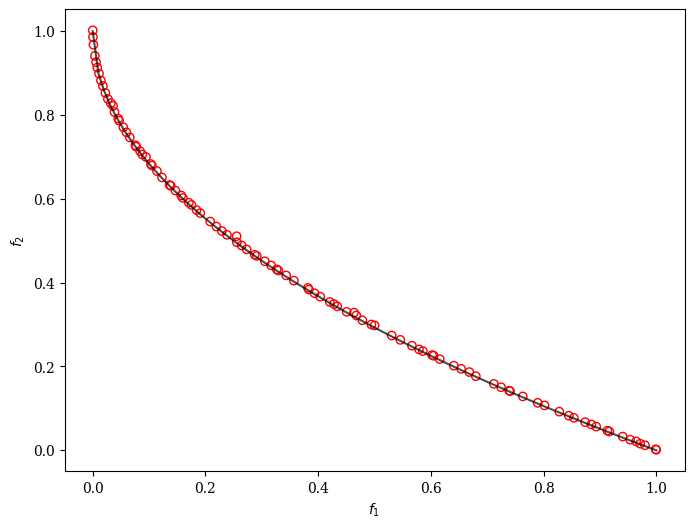

In [64]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter


import pymoo.gradient.toolbox as anp
from pymoo.core.problem import Problem


class ZDT(Problem):
    def __init__(self, n_var=30, **kwargs):
        super().__init__(n_var=n_var, n_obj=2, xl=0, xu=1, vtype=float, **kwargs)


class ZDT1(ZDT):
    def _calc_pareto_front(self, n_pareto_points=100):
        x = np.linspace(0, 1, n_pareto_points)
        return np.array([x, 1 - np.sqrt(x)]).T

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = x[:, 0]
        g = 1 + 9.0 / (self.n_var - 1) * anp.sum(x[:, 1:], axis=1)
        f2 = g * (1 - anp.power((f1 / g), 0.5))

        out["F"] = anp.column_stack([f1, f2])

problem = ZDT1()

algorithm = NSGA2(pop_size=100)

res = minimize(problem, algorithm, ("n_gen", 200), seed=1, verbose=False)

plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.show()


In [ ]:
# 6x4 Implementation of Pokémon Team Problem with Constraints

import numpy as np
from numpy._typing._array_like import NDArray
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from pymoo.core.sampling import Sampling
import random
from pymoo.core.mutation import Mutation
from pymoo.core.crossover import Crossover
from pymoo.operators.mutation.nom import NoMutation


# === CONFIGURATION ===
n_pokemon = 1302
n_moves = 459
n_types = 18
n_stats = 6
LM = np.random.randint(
    0, 2, size=(n_pokemon, n_moves), dtype=bool
)  # Replace with actual - Learnable Moves
ME = np.random.randint(
    20, 110, size=(2, n_moves), dtype=np.int64
)  # Replace with actual - Move Effectiveness
# Make sure ME has only one value per column
for col in range(ME.shape[1]):
    row = random.randint(0, 1)
    ME[row, col] = 0
PT = np.random.randint(
    0, 2, size=(n_pokemon, n_types), dtype=bool
)  # Replace with actual - Pokémon Types
MT = np.random.randint(
    0, 2, size=(n_moves, n_types), dtype=bool
)  # Replace with actual - Move Types
PS = np.random.randint(
    20, 110, size=(n_pokemon, n_stats), dtype=np.int64
)  # Replace with actual - Pokémon Stats
Att = [
    0,
    1,
    1,
    0,
    0,
    0,
]  # Replace with actual - Vector to chose attack and special attack stats


# === PROBLEM WITH CONSTRAINTS ===
class PokemonTeamProblemWithConstraints(Problem):
    def __init__(self, LM=LM, ME=ME, n_pokemon=n_pokemon, n_moves=n_moves, repeat_pokemon=False, pokemon_in_team=6):
        self.n_pokemon = n_pokemon
        self.n_moves = n_moves
        self.LM = LM.astype(bool)  # Learnable Moves
        self.ME = ME.astype(np.int64)  # Move Effectiveness
        self.repeat_pokemon = repeat_pokemon
        self.pokemon_in_team = pokemon_in_team
        super().__init__(
            n_var=self.pokemon_in_team + self.pokemon_in_team * 4,  # 6 pokemon by 4 moves
            n_obj=2,
            n_ieq_constr=self.pokemon_in_team * 4
            + self.pokemon_in_team
            + 1
            * self.repeat_pokemon,  # The 4 moves of each 6 pokemon must be learnable. Each pokemon has 4 different moves
            xl=0,
            xu=n_pokemon,
            type_var=np.uint16,
        )

    def _evaluate(self, X, out, *args, **kwargs):
        F = []
        G = []

        for ind in X:
            x = ind[:self.pokemon_in_team]
            y = ind[self.pokemon_in_team:].reshape(self.pokemon_in_team, 4)

            # === Objectives ===
            # x contains the row indexes, y contains the column indexes for ME
            # For each pair (xi, yi), sum ME[xi, yi]

            prefilter_pokemon_rows = np.repeat(x, 4)
            prefilter_move_columns = y.flatten()
            # Filter out moves with value -1 and their corresponding pokemon_rows
            valid_mask = prefilter_move_columns != -1
            pokemon_rows = prefilter_pokemon_rows[valid_mask]
            move_columns = prefilter_move_columns[valid_mask]
            damage = ME[:, move_columns].sum()
            damage2 = ME[:, move_columns].sum()*2
            F.append([-damage, -damage2])  # negative = maximize

            # === Constraints ===
            constraints = []

            # Moves in the positions of x_i and y_i are learnable: 1 - LM_xi,yi ≤ 0
            constraints += list((1 - self.LM[pokemon_rows, move_columns]).flatten())

            # Not repeated moves: len(yi) - len(set(yi)) ≤ 0
            constraints += list(
                (
                    np.apply_along_axis(
                        lambda row: len(row[row >= 0]) - len(set(row[row >= 0])), 1, y
                    )
                )
            )

            # no repeated Pokemon: len(x) - len(set(x)) ≤ 0
            if self.repeat_pokemon:
                constraints += list((len(set(x)) - len(x)).flatten())

            G.append(constraints)

        out["F"] = np.array(F)
        out["G"] = np.array(G)

def get_random_moves(LM: np.ndarray, i: int) -> np.ndarray[np.int16]:
    legal_moves = np.where(LM[i])[0]
    chosen = -1*np.ones(4, dtype=np.int16)
    if len(legal_moves) >= 4:
        selected = np.random.choice(legal_moves, 4, replace=False)
    else:
        # Optional: fallback to random other Pokémon if not enough moves
        selected = np.random.choice(
            legal_moves, len(legal_moves), replace=False
        )
    chosen[: selected.shape[0]] = selected
    return chosen

class PokemonTeamSampling(Sampling):
    def __init__(self):
        super().__init__()

    def _do(self, problem, n_samples, **kwargs):
        individuals = []

        for _ in range(n_samples):
            # (1) Select 6 unique Pokémon
            team = np.random.choice(problem.n_pokemon, problem.pokemon_in_team, replace=False)

            # (2) Assign 4 legal moves to each selected Pokémon
            moves = np.zeros((problem.pokemon_in_team, 4), dtype=np.int16)

            for j, i in enumerate(team):
                legal_moves = np.where(problem.LM[i])[0]
                chosen = -1*np.ones(4, dtype=np.int16)
                if len(legal_moves) >= 4:
                    selected = np.random.choice(legal_moves, 4, replace=False)
                else:
                    # Optional: fallback to random other Pokémon if not enough moves
                    selected = np.random.choice(
                        legal_moves, len(legal_moves), replace=False
                    )
                chosen[:selected.shape[0]] = selected
                moves[j] = chosen

            # Flatten and concatenate
            indiv = np.concatenate([team, moves.flatten()])
            individuals.append(indiv)

        return np.array(individuals)


class PokemonMutation(Mutation):
    def __init__(self, prob_pokemon=0.01, prob_move=0.001):
        super().__init__()
        self.prob_pokemon = prob_pokemon
        self.prob_move = prob_move

    def pokemon_mutation(self, x, y, LM):
        not_chosen_pokemon = [i for i in range(n_pokemon) if i not in x]
        possible_new_pokemon = np.random.choice(not_chosen_pokemon, size=x.shape[0])

        mutated_pokemon_mask = np.random.rand(x.shape[0]) < self.prob_pokemon
        mutated_team = np.where(
            mutated_pokemon_mask,
            possible_new_pokemon,
            x,
        )

        mutated_moves = y.copy()
        for j, i in enumerate(mutated_team):
            if mutated_pokemon_mask[j]:
                mutated_moves[j] = get_random_moves(LM, i)
        return mutated_team, mutated_moves

    def move_mutation(self, x, y, LM):
        pokemon_in_team = x.shape[0]
        mutated_moves_mask = np.random.rand(y.shape[0], y.shape[1]) < self.prob_move
        rows_with_mutations = np.any(mutated_moves_mask, axis=1)
        pokemon_with_mutations = x[rows_with_mutations]
        possible_new_moves = np.zeros((pokemon_in_team, 4), dtype=np.int16)
        modified_LM = self.modify_LM(LM, x, y) # TODO This is forcing moves to change, but if the pokemon doesnt have any more moves, it will lose a move. IT should let moves be repicked if that's the case
        for i in pokemon_with_mutations:
            possible_new_moves[np.where(x == i)[0][0]] = get_random_moves(
                modified_LM, i
            )
        mutated_moves = np.where(
            np.logical_and(mutated_moves_mask, possible_new_moves >= 0),
            possible_new_moves,
            y,
        )
        return mutated_moves

    def modify_LM(self, LM, x, y):
        modified_LM = LM.copy()
        for x_i, x_val in enumerate(x):
            for y_i in y[x_i]:
                modified_LM[x_val, y_i] = 0
        return modified_LM

    def _do(self, problem, X, **kwargs):
        n_pokemon = problem.n_pokemon
        n_moves = problem.n_moves

        for ind in X:
            x = ind[: problem.pokemon_in_team]
            y = ind[problem.pokemon_in_team :].reshape(problem.pokemon_in_team, 4)
            mutated_team = x.copy()
            mutated_moves = y.copy()

            mutated_team, mutated_moves = self.pokemon_mutation(x, y, problem.LM)

            # ==== Move mutation ====
            # mutated_moves = self.move_mutation(mutated_team, mutated_moves, problem.LM)

            ind[: problem.pokemon_in_team] = mutated_team
            ind[problem.pokemon_in_team :] = mutated_moves.flatten()

        return X


class PokemonCrossover(Crossover):
    def __init__(self, prob_pokemon=0.5):
        super().__init__(2, 2)  # 2 parents → 2 offspring
        self.prob_pokemon = prob_pokemon

    def _do(self, problem, X, **kwargs):
        n_parents, n_matings, n_vars = X.shape
        pokemon_in_team = problem.pokemon_in_team

        offspring = np.empty_like(X)

        for k in range(n_matings):
            parent1 = X[0][k]
            parent2 = X[1][k]

            # CASE 1: If both parents are identical, just copy them
            if np.all(parent1 == parent2):
                offspring[0][k] = parent1.copy()
                offspring[1][k] = parent2.copy()
                continue

            # Split into X and Y
            x1, y1 = (
                parent1[:pokemon_in_team],
                parent1[pokemon_in_team:].reshape(pokemon_in_team, 4),
            )
            x2, y2 = (
                parent2[:pokemon_in_team],
                parent2[pokemon_in_team:].reshape(pokemon_in_team, 4),
            )

            parent1_src1 = (
                np.random.rand() < self.prob_pokemon
            )  # True if child1 is based on parent 1, False if based on parent 2
            parent1_src2 = (
                np.random.rand() > self.prob_pokemon
            )  # True if child2 is based on parent 1, False if based on parent 2
            child1 = parent1.copy() if parent1_src1 else parent2.copy()
            child2 = parent1.copy() if parent1_src2 else parent2.copy()


            child1_x, child1_y = (
                child1[:pokemon_in_team],
                child1[pokemon_in_team:].reshape(pokemon_in_team, 4),
            )
            child2_x, child2_y = (
                child2[:pokemon_in_team],
                child2[pokemon_in_team:].reshape(pokemon_in_team, 4),
            )

            # --- Perform crossover on x (pokémon IDs) ---
            n_crossovers = np.random.randint(1, pokemon_in_team)
            common = set(x1) & set(x2)
            indices1 = [i for i in range(len(x1)) if x1[i] not in common]
            indices2 = [j for j in range(len(x2)) if x2[j] not in common]
            np.random.shuffle(indices1)
            np.random.shuffle(indices2)
            n_crossovers = min(n_crossovers, len(indices1), len(indices2))
            done_crossovers = 0
            for i1, i2 in zip(indices1[:n_crossovers], indices2[:n_crossovers]):
                val1 = x2[i1] if parent1_src1 else x1[i1]
                val2 = x2[i2] if parent1_src2 else x1[i2]
                if val1 not in child1_x:
                    if val2 not in child2_x:
                        m1 = y2[i1] if parent1_src1 else y1[i1]
                        m2 = y2[i2] if parent1_src2 else y1[i2]
                        child1_x[i1], child2_x[i2] = val1, val2
                        child1_y[i1], child2_y[i2] = (
                            m1.copy(),
                            m2.copy(),
                        )
                        done_crossovers += 1
                        # print(f"Done crossovers: {done_crossovers}/{n_crossovers}")

            # Combine x and y back into flattened vectors
            offspring[0][k] = np.concatenate([child1_x, child1_y.flatten()])
            offspring[1][k] = np.concatenate([child2_x, child2_y.flatten()])

        return offspring


# === ALGORITHM SETUP ===
algorithm = NSGA2(
    pop_size=100,
    sampling=PokemonTeamSampling(),
    crossover=PokemonCrossover(prob_pokemon=0.5),
    mutation=PokemonMutation(prob_pokemon=0.5, prob_move=0.5),
    eliminate_duplicates=True,
)

termination = get_termination("n_gen", 100)

res = minimize(
    problem=PokemonTeamProblemWithConstraints(
        LM=LM, ME=ME, n_pokemon=n_pokemon, n_moves=n_moves
    ),
    algorithm=algorithm,
    termination=termination,
    seed=1,
    verbose=True,
    save_history=True,
)

# === RESULTS ===
print("Best solutions on Pareto front:")
if len(res.F) > 2:
    for f, x in zip(res.F, res.X):
        print(f, "(Pokémon count:", x[:n_pokemon].sum(), ")")
else:
    print(res.F, "(Pokémon count:", res.X[:n_pokemon].sum(), ")")


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      1 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      200 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     3 |      300 |      1 |  0.000000E+00 |  0.000000E+00 |  3.980000E+02 |         ideal
     4 |      400 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     5 |      500 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     6 |      600 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     7 |      700 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     8 |      800 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     9 |      900 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
    10 |     1000 |      1 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f

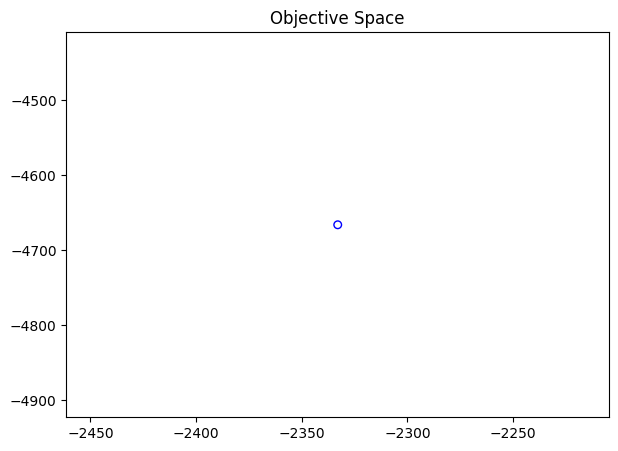

In [17]:
import matplotlib.pyplot as plt
F = res.F
plt.figure(figsize=(7, 5))
plt.scatter(F[:, 0], F[:, 1], s=30, facecolors='none', edgecolors='blue')
plt.title("Objective Space")
plt.show()


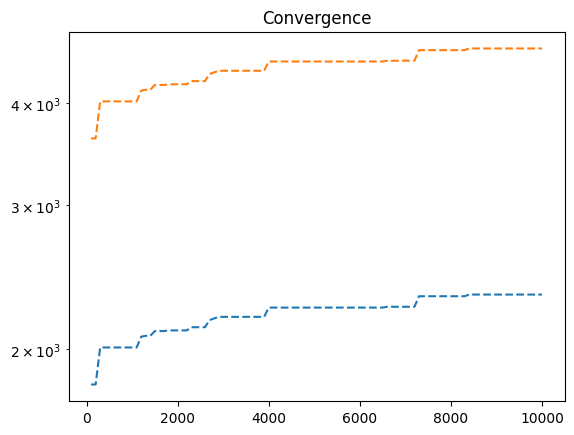

In [18]:
import numpy as np
import matplotlib.pyplot as plt

n_evals = np.array([e.evaluator.n_eval for e in res.history])
opt = np.array([e.opt[0].F for e in res.history])

plt.title("Convergence")
plt.plot(n_evals, abs(opt), "--")
plt.yscale("log")
plt.show()
